# Курсовой проект: Очистка и анализ данных о продажах автомобилей в Казахстане (2019)
## Автоцентр "Меркур Авто"

In [2]:
import pandas as pd
import numpy as np
from datetime import datetime
import pycountry
import warnings
warnings.filterwarnings('ignore')

# Для визуализации (EDA)
import matplotlib.pyplot as plt
import seaborn as sns
plt.style.use('seaborn-v0_8-darkgrid')

### 2. Загрузка и первичный осмотр данных

In [4]:
# Загрузка данных с правильным разделителем и десятичным разделителем
df = pd.read_csv('/Users/roman/Desktop/git/maga/eda/autokz2019.csv', sep=';', decimal=',', encoding='utf-8')

# Просмотр первых строк
print("Первые 5 строк данных:")
print(df.head())
print("\n" + "="*80 + "\n")

# Размер данных
print(f"Размер данных: {df.shape[0]} строк, {df.shape[1]} столбцов")
print("\n" + "="*80 + "\n")

# Информация о типах данных
print("Информация о типах данных:")
print(df.info())
print("\n" + "="*80 + "\n")

# Пропущенные значения
print("Пропущенные значения по столбцам:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])
print("\n" + "="*80 + "\n")

# Статистика по числовым столбцам
print("Описательная статистика числовых столбцов:")
print(df.describe())

Первые 5 строк данных:
    Год   Месяц     Компания Бренд Модель Модификация Год выпуска  \
0  2019     Май  Mercur Auto  Audi     A3        TFSI        2018   
1  2019  Август  Mercur Auto  Audi     A3        TFSI        2018   
2  2019  Апрель  Mercur Auto  Audi     A4        TFSI        2018   
3  2019    Июль  Mercur Auto  Audi     A4        TFSI        2018   
4  2019    Июль  Mercur Auto  Audi     A4        TFSI        2018   

  Страна-производитель Вид топлива Объём двиг, л,  ... Тип клиента  \
0             Германия      Бензин            1,4  ...   Физ. Лицо   
1             Германия      Бензин            1,4  ...    Юр. Лицо   
2             Германия      Бензин            1,4  ...   Физ. Лицо   
3             Германия      Бензин            1,4  ...    Юр. Лицо   
4             Германия      Бензин            1,4  ...   Физ. Лицо   

  Форма расчета Количество Цена, USD Продажа, USD   Область  \
0   безналичный        1.0  28115.00     28115.00  г.Алматы   
1      наличный

### 3. Предварительная очистка данных

In [6]:
# Создаем копию данных для работы
df_clean = df.copy()

# Удаляем столбцы, которые не несут аналитической ценности (по ТЗ)
columns_to_drop = ['Дилер', 'Тип платежа', 'Сегмент', 'Сегмент ЕПР', 'Локализация', 
                   'Тип клиента', 'Модификация', 'Форма расчета', 'Сегментация Eng', 
                   'Локализация производства']
# Оставляем только те столбцы, которые есть в данных
existing_columns_to_drop = [col for col in columns_to_drop if col in df_clean.columns]
df_clean = df_clean.drop(columns=existing_columns_to_drop)

# Переименовываем столбцы на английский язык (согласно ТЗ)
column_mapping = {
    'Год': 'Year',
    'Месяц': 'Month',
    'Компания': 'Company',
    'Бренд': 'Brand',
    'Модель': 'Model',
    'Год выпуска': 'Production_Year',
    'Страна-производитель': 'Country',
    'Вид топлива': 'Fuel_Type',
    'Объём двиг, л,': 'Engine_Volume',
    'Коробка передач': 'Transmission',
    'Тип привода': 'Drive_Type',
    'Регион': 'Region',
    'Наименование дилерского центра': 'Dealer_Center',
    'Количество': 'Quantity',
    'Цена, USD': 'Price_USD',
    'Продажа, USD': 'Total_Price_USD',
    'Область': 'Area',
    'Сегментация 2013': 'Segment_2013',
    'Класс 2013': 'Class_2013'
}

df_clean = df_clean.rename(columns=column_mapping)

# Удаляем полностью пустые строки
df_clean = df_clean.dropna(how='all')

# Удаляем явные дубликаты
initial_rows = df_clean.shape[0]
df_clean = df_clean.drop_duplicates()
removed_duplicates = initial_rows - df_clean.shape[0]
print(f"Удалено явных дубликатов: {removed_duplicates}")

# Проверяем текущее состояние
print(f"\nТекущий размер данных: {df_clean.shape}")
print("\nСтолбцы после переименования:")
print(df_clean.columns.tolist())

Удалено явных дубликатов: 21987

Текущий размер данных: (17979, 19)

Столбцы после переименования:
['Year', 'Month', 'Company', 'Brand', 'Model', 'Production_Year', 'Country', 'Fuel_Type', 'Engine_Volume', 'Transmission', 'Drive_Type', 'Region', 'Dealer_Center', 'Quantity', 'Price_USD', 'Total_Price_USD', 'Area', 'Segment_2013', 'Class_2013']


### 4. Глубокая очистка и преобразование данных

In [8]:
# 4.1 Страна производства: преобразуем в ALPHA-3 коды
def get_country_code(country_name):
    """Получение кода страны ALPHA-3 по названию"""
    try:
        # Обработка специальных случаев
        if pd.isna(country_name):
            return None
        country_name = str(country_name).strip()
        
        # Маппинг для стран, которые могут не распознаться
        country_mapping = {
            'Россия': 'RUS',
            'Российская Федерация': 'RUS',
            'Казахстан': 'KAZ',
            'Германия': 'DEU',
            'США': 'USA',
            'Соединенные Штаты': 'USA',
            'Соединенные Штаты Америки': 'USA',
            'Япония': 'JPN',
            'Корея': 'KOR',
            'Южная Корея': 'KOR',
            'Чехия': 'CZE',
            'Франция': 'FRA',
            'Италия': 'ITA',
            'Великобритания': 'GBR',
            'Китай': 'CHN',
            'Индия': 'IND',
            'Бразилия': 'BRA',
            'Австрия': 'AUT',
            'Республика Казахстан': 'KAZ',
            'Таиланд': 'THA',
            'Узбекистан': 'UZB',
            'Венгрия': 'HUN', 
            'Турция': 'TUR', 
            'Испания': 'ESP', 
            'Нидерланды': 'NLD',
            'Польша': 'POL', 
            'Швеция': 'SWE', 
            'Белоруссия': 'BLR',
            'Бельгия': 'BEL'
        }
        
        # Проверяем маппинг сначала
        if country_name in country_mapping:
            return country_mapping[country_name]
        
        # Ищем в библиотеке pycountry
        try:
            country = pycountry.countries.search_fuzzy(country_name)[0]
            return country.alpha_3
        except:
            # Если не нашли, возвращаем оригинальное название
            return country_name
    except:
        return country_name

# Применяем функцию к столбцу Country
print("Преобразование стран в ALPHA-3 коды...")
df_clean['Country_Code'] = df_clean['Country'].apply(get_country_code)
print(f"Уникальные коды стран: {df_clean['Country_Code'].nunique()}")

# 4.2 Вид топлива: кодируем в краткие категории
fuel_mapping = {
    'Бензин': 'F',
    'бензин ': 'F',
    '2': 'F',
    '1,6': 'F',
    '0': 'F',
    'Дизель': 'D',
    'дизель ': 'D',
    'Электро': 'E',
    'Электричество': 'E',
    'Гибрид': 'HYB',
    'гибрид': 'HYB',
    'Гибрид (бензин/электрический)': 'HYB',
    'Гибрид (дизель/электрический)': 'HYB'
}

df_clean['Fuel_Type_Code'] = df_clean['Fuel_Type'].map(fuel_mapping)
# Заполняем пропущенные значения оригинальными (для дальнейшего анализа)
df_clean['Fuel_Type_Code'] = df_clean['Fuel_Type_Code'].fillna(df_clean['Fuel_Type'])

# 4.3 Тип привода: стандартизируем
drive_type_mapping = {
    'передний': 'FWD',
    'Астана' : '4WD', 
    'FWD': 'FWD',
    'Передний': 'FWD',
    'задний': 'RWD',
    'RWD': 'RWD',
    'Задний': 'RWD',
    '4х2.2': 'RWD',
    'полный': '4WD',
    'Полный': '4WD',
    '4WD': '4WD',
    '4 WD': '4WD',
    '4x4': '4WD',
    '4X4': '4WD',
    '4х4': '4WD',
    'AWD': '4WD',
    '2 WD': 'FWD',
    '2WD': 'FWD',
    '4x2': 'FWD',
    '4х2': 'FWD',
    '4X2': 'FWD',
    'Передний (FF)': 'FWD',
    '0': 'FWD',
    'FF': 'FWD',
    'Полный': '4WD',
    '#Н/Д': '4WD',
    'Полный привод': '4WD',
    '4Motion': '4WD',
    'quattro': '4WD',  # Для Audi
    'xDrive': '4WD',   # Для BMW
    '4MATIC': '4WD'    # Для Mercedes
}

df_clean['Drive_Type_Standard'] = df_clean['Drive_Type'].map(drive_type_mapping)
df_clean['Drive_Type_Standard'] = df_clean['Drive_Type_Standard'].fillna(df_clean['Drive_Type'])

# 4.4 Числовые столбцы: преобразуем к корректным числовым типам
# Сначала заменяем запятые на точки и убираем пробелы
def clean_numeric(value):
    if pd.isna(value):
        return value
    try:
        # Если это строка, очищаем её
        if isinstance(value, str):
            value = value.replace(',', '.').replace(' ', '')
        return float(value)
    except:
        return value

numeric_columns = ['Price_USD', 'Quantity', 'Total_Price_USD']
for col in numeric_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].apply(clean_numeric)
        df_clean[col] = pd.to_numeric(df_clean[col], errors='coerce')

# Анализируем аномалии в Quantity
print("\nАнализ аномалий в количестве (Quantity):")
print(f"Минимальное количество: {df_clean['Quantity'].min()}")
print(f"Максимальное количество: {df_clean['Quantity'].max()}")
print(f"Количество продаж с Quantity < 0: {(df_clean['Quantity'] < 0).sum()}")
print(f"Количество продаж с Quantity > 10: {(df_clean['Quantity'] > 10).sum()}")

# Ищем оптовые заказы (например, много Skoda)
brand_quantity_stats = df_clean.groupby('Brand')['Quantity'].sum().sort_values(ascending=False)
print("\nТоп-5 брендов по общему количеству проданных авто:")
print(brand_quantity_stats.head())

Преобразование стран в ALPHA-3 коды...
Уникальные коды стран: 19

Анализ аномалий в количестве (Quantity):
Минимальное количество: -1.0
Максимальное количество: 115.0
Количество продаж с Quantity < 0: 1
Количество продаж с Quantity > 10: 396

Топ-5 брендов по общему количеству проданных авто:
Brand
Lada       11079.0
Hyundai     4017.0
Toyota      3134.0
Kia         2346.0
Nissan      1625.0
Name: Quantity, dtype: float64


In [9]:
# 4.5 Создаем столбец Дата продажи
# Маппинг месяцев на номера
month_mapping = {
    'Январь': 1, 'Февраль': 2, 'Март': 3, 'Апрель': 4, 'Май': 5, 'Июнь': 6,
    'Июль': 7, 'Август': 8, 'Сентябрь': 9, 'Октябрь': 10, 'Ноябрь': 11, 'Декабрь': 12
}

# Преобразуем месяц в число
df_clean['Month_Number'] = df_clean['Month'].map(month_mapping)

# Создаем дату (последний день месяца)
def create_date(row):
    try:
        year = int(row['Year'])
        month = int(row['Month_Number'])
        # Определяем последний день месяца
        if month in [4, 6, 9, 11]:
            day = 30
        elif month == 2:
            # Проверяем високосный год
            if (year % 4 == 0 and year % 100 != 0) or (year % 400 == 0):
                day = 29
            else:
                day = 28
        else:
            day = 31
        return datetime(year, month, day)
    except:
        return pd.NaT

df_clean['Sale_Date'] = df_clean.apply(create_date, axis=1)

# Удаляем исходные столбцы Год и Месяц
df_clean = df_clean.drop(columns=['Year', 'Month', 'Month_Number'])

# 4.6 Название компании: удаляем неявные дубликаты
# Стандартизируем названия
company_mapping = {
    'Mercur Auto': 'Меркур Авто',
    'Mercur Auto ': 'Меркур Авто',
    'Mercur Auto Алматы': 'Меркур Авто',
    'Mercur Auto Астана': 'Меркур Авто',
    'Mercur Autos': 'Меркур Авто',
    'Astana Motors ': 'Astana Motors',
    'MMC RUS': 'ММС Рус',
    'Ravon Motors Kazakstan': 'Равон Моторс Казахстан',
    'Hino Motors ': 'Хино Моторс Казахстан',
    'Каспиан Моторс': 'Caspian Motors'
}

# Применяем маппинг для стандартизации
for wrong_name, correct_name in company_mapping.items():
    df_clean.loc[df_clean['Company'] == wrong_name, 'Company'] = correct_name

print(f"\nУникальных компаний после очистки: {df_clean['Company'].nunique()}")


Уникальных компаний после очистки: 34


In [10]:
# 4.7 Объём двигателя: сложная очистка (исправленная версия)
def clean_engine_volume(value):
    if pd.isna(value):
        return np.nan
    
    try:
        # Преобразуем в строку
        value_str = str(value).strip()
        
        # Пропускаем пустые строки
        if not value_str:
            return np.nan
            
        # Удаляем литеру L
        value_str = value_str.replace('L', '').replace('l', '')
        
        # Заменяем запятые на точки
        value_str = value_str.replace(',', '.')
        
        # Убираем лишние пробелы
        value_str = value_str.replace(' ', '')
        
        # Удаляем нечисловые символы, кроме точки и минуса
        value_str = ''.join(char for char in value_str if char.isdigit() or char in '.-')
        
        # Проверяем, что строка не пустая после очистки
        if not value_str:
            return np.nan
            
        # Преобразуем в число
        try:
            volume = float(value_str)
        except ValueError:
            return np.nan
        
        # Исправляем очевидные ошибки
        # Jaguar с объемом 400 (вероятно, перепутаны объем и мощность)
        if volume > 100:  # Нереальный объем двигателя
            # Делим на 10, предполагая, что это мощность в л.с.
            volume = volume / 10
        
        # Исправляем аномалии для Chevrolet Niva
        if volume > 10 and volume < 30:  # Значения типа 21.6, 20.6
            volume = volume / 10
            
        # Проверяем на разумные пределы объема двигателя
        if volume < 0.5 or volume > 10:  # Нереальные значения
            return np.nan
        
        return round(volume, 1)
    except:
        return np.nan

print("\nОчистка объема двигателя...")
df_clean['Engine_Volume_Clean'] = df_clean['Engine_Volume'].apply(clean_engine_volume)

# Преобразуем в числовой тип, обрабатывая ошибки
df_clean['Engine_Volume_Clean'] = pd.to_numeric(df_clean['Engine_Volume_Clean'], errors='coerce')

# Проверяем результаты
print(f"Минимальный объем двигателя: {df_clean['Engine_Volume_Clean'].min():.1f}")
print(f"Максимальный объем двигателя: {df_clean['Engine_Volume_Clean'].max():.1f}")
print(f"Средний объем двигателя: {df_clean['Engine_Volume_Clean'].mean():.2f}")

# Показываем проблемные строки (если есть)
problematic_rows = df_clean[df_clean['Engine_Volume_Clean'].isna() & df_clean['Engine_Volume'].notna()]
if len(problematic_rows) > 0:
    print(f"\nНайдено проблемных строк с объемом двигателя: {len(problematic_rows)}")
    print("Примеры проблемных значений:")
    for val in df_clean['Engine_Volume'].dropna().unique()[:10]:
        cleaned = clean_engine_volume(val)
        print(f"  '{val}' -> {cleaned}")

# 4.8 Регион и область: нормализуем регистр
def normalize_text(text):
    if pd.isna(text):
        return text
    try:
        # Приводим каждое слово к заглавной первой букве
        return ' '.join(word.capitalize() for word in str(text).split())
    except:
        return text

df_clean['Region'] = df_clean['Region'].apply(normalize_text)
df_clean['Area'] = df_clean['Area'].apply(normalize_text)

# 4.9 Тип трансмиссии: упрощаем до двух категорий
transmission_mapping = {
    # Автоматическая коробка передач
    'АКПП': 'Автомат',
    'АКП': 'Автомат',
    'Автомат': 'Автомат',
    'AT': 'Автомат',
    'АT': 'Автомат',
    'АТ': 'Автомат',
    'A/T': 'Автомат',
    'А/T': 'Автомат',
    
    # Специфичные автоматические коробки
    'Tiptronic': 'Автомат',
    'Steptronic': 'Автомат',
    'S-tronic': 'Автомат',
    'S-Tronic': 'Автомат',
    'DSG': 'Автомат',
    'DCT': 'Автомат',
    'PDK': 'Автомат',
    'CVT': 'Автомат',
    'CVT (вариатор)': 'Автомат',
    'CVT (вариATор)': 'Автомат',
    'CVT(вAриATор)': 'Автомат',
    'AMT': 'Автомат',
    'Powershift S6': 'Автомат',
    '7G-TRONIC': 'Автомат',
    '9G-TRONIC': 'Автомат',
    
    # Механическая коробка передач
    'МКПП': 'Механика',
    'МКП': 'Механика',
    'Механика': 'Механика',
    'Мех.': 'Механика',
    'MT': 'Механика',
    'МT': 'Механика',
    'МТ': 'Механика',
    'M/T': 'Механика',
    'М/T': 'Механика',
    'Ручная': 'Механика',
    'Механическая': 'Механика',
    
    # С цифрами (автомат)
    '4 AT': 'Автомат',
    '4 АТ': 'Автомат',
    '4AT': 'Автомат',
    '4АТ': 'Автомат',
    '5 AT': 'Автомат',
    '5AT': 'Автомат',
    '5АТ': 'Автомат',
    '6 AT': 'Автомат',
    '6 AT': 'Автомат',
    '6AT': 'Автомат',
    '6АТ': 'Автомат',
    '6 АТ': 'Автомат',
    '6А': 'Автомат',
    '6A': 'Автомат',
    '6 DSG': 'Автомат',
    '6DSG': 'Автомат',
    '7 AT': 'Автомат',
    '7AT': 'Автомат',
    '7АКП': 'Автомат',
    '7 АКП': 'Автомат',
    '7АТ': 'Автомат',
    '7 DCT': 'Автомат',
    '7DCT': 'Автомат',
    '7 DSG': 'Автомат',
    '7DSG': 'Автомат',
    '7 АКПП (PDK)': 'Автомат',
    '7 АКПП PDK': 'Автомат',
    '8 AT': 'Автомат',
    '8AT': 'Автомат',
    '8АТ': 'Автомат',
    '8 АТ': 'Автомат',
    '8АКПП': 'Автомат',
    '8 A': 'Автомат',
    '8A': 'Автомат',
    '8 АКПП (PDK)': 'Автомат',
    '8 АКПП Tiptronic S': 'Автомат',
    '8-ступ АКПП': 'Автомат',
    '9AT': 'Автомат',
    '12AT': 'Автомат',
    '12АТ': 'Автомат',
    
    # С цифрами (механика)
    '5 MT': 'Механика',
    '5MT': 'Механика',
    '5МТ': 'Механика',
    '5 МТ': 'Механика',
    '5M': 'Механика',
    '5М': 'Механика',
    '6 MT': 'Механика',
    '6MT': 'Механика',
    '6 МТ': 'Механика',
    '6МТ': 'Механика',
    '6M/T': 'Механика',
    
    # Неопределенные/некорректные значения
    '#Н/Д': 'Н/Д',  # можно заменить на 'Неизвестно' или оставить None
    '0': 'Н/Д',
    '8': 'Н/Д',
    '4WD': 'Н/Д',  # это тип привода, не трансмиссия
    'TDI': 'Н/Д',  # это тип двигателя
    'Передний': 'Н/Д',  # это тип привода
    'РЕДУКТОР': 'Н/Д',  # это не трансмиссия
}

df_clean['Transmission_Simple'] = df_clean['Transmission'].map(transmission_mapping)
df_clean['Transmission_Simple'] = df_clean['Transmission_Simple'] #.fillna(df_clean['Transmission'])


Очистка объема двигателя...
Минимальный объем двигателя: 1.1
Максимальный объем двигателя: 9.7
Средний объем двигателя: 2.27

Найдено проблемных строк с объемом двигателя: 42
Примеры проблемных значений:
  '1,4' -> 1.4
  '2' -> 2.0
  '3' -> 3.0
  '4,4' -> 4.4
  '6,6' -> 6.6
  '1,5' -> 1.5
  '1,596' -> 1.6
  '2,4' -> 2.4
  '1,7' -> 1.7
  '26,7' -> 2.7


In [11]:
# 4.10 Финальные преобразования типов данных
# Дата продажи в datetime
df_clean['Sale_Date'] = pd.to_datetime(df_clean['Sale_Date'])

# Категориальные столбцы
categorical_columns = ['Fuel_Type_Code', 'Transmission_Simple', 'Drive_Type_Standard', 
                       'Segment_2013', 'Class_2013', 'Company', 'Brand', 'Model', 
                       'Country_Code', 'Region', 'Area']

for col in categorical_columns:
    if col in df_clean.columns:
        df_clean[col] = df_clean[col].astype('category')

# Удаляем старые столбцы, которые были заменены
columns_to_drop_final = ['Country', 'Fuel_Type', 'Drive_Type', 'Transmission', 'Engine_Volume']
df_clean = df_clean.drop(columns=[col for col in columns_to_drop_final if col in df_clean.columns])

# Переименовываем очищенные столбцы
df_clean = df_clean.rename(columns={
    'Country_Code': 'Country',
    'Fuel_Type_Code': 'Fuel_Type',
    'Drive_Type_Standard': 'Drive_Type',
    'Transmission_Simple': 'Transmission',
    'Engine_Volume_Clean': 'Engine_Volume'
})

# Реорганизуем порядок столбцов для удобства
column_order = [
    'Sale_Date', 'Company', 'Brand', 'Model', 'Production_Year', 
    'Country', 'Fuel_Type', 'Engine_Volume', 'Transmission', 'Drive_Type',
    'Region', 'Area', 'Dealer_Center', 'Segment_2013', 'Class_2013',
    'Quantity', 'Price_USD', 'Total_Price_USD'
]

# Оставляем только те столбцы, которые есть в данных
final_columns = [col for col in column_order if col in df_clean.columns]
df_clean = df_clean[final_columns]

print("\n" + "="*80)
print("Глубокая очистка завершена!")
print(f"Финальный размер данных: {df_clean.shape}")
print("\nПервые 5 строк очищенных данных:")
print(df_clean.head())


Глубокая очистка завершена!
Финальный размер данных: (17979, 18)

Первые 5 строк очищенных данных:
   Sale_Date      Company Brand Model Production_Year Country Fuel_Type  \
0 2019-05-31  Меркур Авто  Audi    A3            2018     DEU         F   
1 2019-08-31  Меркур Авто  Audi    A3            2018     DEU         F   
2 2019-04-30  Меркур Авто  Audi    A4            2018     DEU         F   
3 2019-07-31  Меркур Авто  Audi    A4            2018     DEU         F   
5 2019-02-28  Меркур Авто  Audi    A6            2017     DEU         F   

   Engine_Volume Transmission Drive_Type      Region          Area  \
0            1.4      Автомат        FWD      Алматы      Г.алматы   
1            1.4      Автомат        FWD      Алматы      Г.алматы   
2            1.4      Автомат        FWD      Алматы      Г.алматы   
3            1.4      Автомат        FWD      Алматы      Г.алматы   
5            2.0      Автомат        4WD  Нур-султан  Г.нур-султан   

        Dealer_Center       

### 5. Исследовательский анализ данных (EDA)

In [14]:
# Создаем копию для анализа
df_eda = df_clean.copy()

# 5.1 Общая статистика
print("="*80)
print("ОБЩАЯ СТАТИСТИКА ДАННЫХ")
print("="*80)

print(f"Общее количество продаж: {df_eda.shape[0]}")
print(f"Общее количество проданных автомобилей: {df_eda['Quantity'].sum():.0f}")
print(f"Общая выручка: ${df_eda['Total_Price_USD'].sum():,.2f}")
print(f"Средняя цена автомобиля: ${df_eda['Price_USD'].mean():,.2f}")
print(f"Медианная цена автомобиля: ${df_eda['Price_USD'].median():,.2f}")
print(f"Период данных: с {df_eda['Sale_Date'].min().strftime('%d.%m.%Y')} по {df_eda['Sale_Date'].max().strftime('%d.%m.%Y')}")

print("\n" + "="*80)
print("РАСПРЕДЕЛЕНИЕ ПО КЛЮЧЕВЫМ ПЕРЕМЕННЫМ")
print("="*80)

# 5.2 Распределение по месяцам
df_eda['Sale_Month'] = df_eda['Sale_Date'].dt.month
monthly_sales = df_eda.groupby('Sale_Month').agg({
    'Quantity': 'sum',
    'Total_Price_USD': 'sum',
    'Price_USD': 'mean'
}).reset_index()

print("\nПродажи по месяцам:")
print(monthly_sales)

ОБЩАЯ СТАТИСТИКА ДАННЫХ
Общее количество продаж: 17979
Общее количество проданных автомобилей: 31828
Общая выручка: $724,148,666.57
Средняя цена автомобиля: $28,163.53
Медианная цена автомобиля: $21,531.38
Период данных: с 31.01.2019 по 30.09.2019

РАСПРЕДЕЛЕНИЕ ПО КЛЮЧЕВЫМ ПЕРЕМЕННЫМ

Продажи по месяцам:
   Sale_Month  Quantity  Total_Price_USD     Price_USD
0           1    2796.0     6.297311e+07  27085.036053
1           2    3031.0     6.503066e+07  27969.645180
2           3    3308.0     7.519690e+07  28031.749211
3           4    4022.0     9.158596e+07  28730.457091
4           5    3774.0     8.984182e+07  28463.068825
5           6    3785.0     8.794483e+07  28859.663391
6           7    3989.0     9.185622e+07  28702.215927
7           8    3797.0     8.429557e+07  27810.632466
8           9    3326.0     7.542360e+07  27418.912217



Топ-10 брендов по количеству проданных автомобилей:
            Quantity  Total_Price_USD
Brand                                
Lada         11079.0     1.077051e+08
Hyundai       4017.0     9.221991e+07
Toyota        3134.0     1.287543e+08
Kia           2346.0     4.541500e+07
Nissan        1625.0     3.896956e+07
UAZ           1166.0     1.610885e+07
GAZ           1139.0     2.023645e+07
Volkswagen    1024.0     2.110671e+07
Skoda          776.0     1.969315e+07
Renault        595.0     8.072545e+06

Распределение по типу топлива:
Fuel_Type
F      16149
D        640
HYB        9
E          4
Name: count, dtype: int64


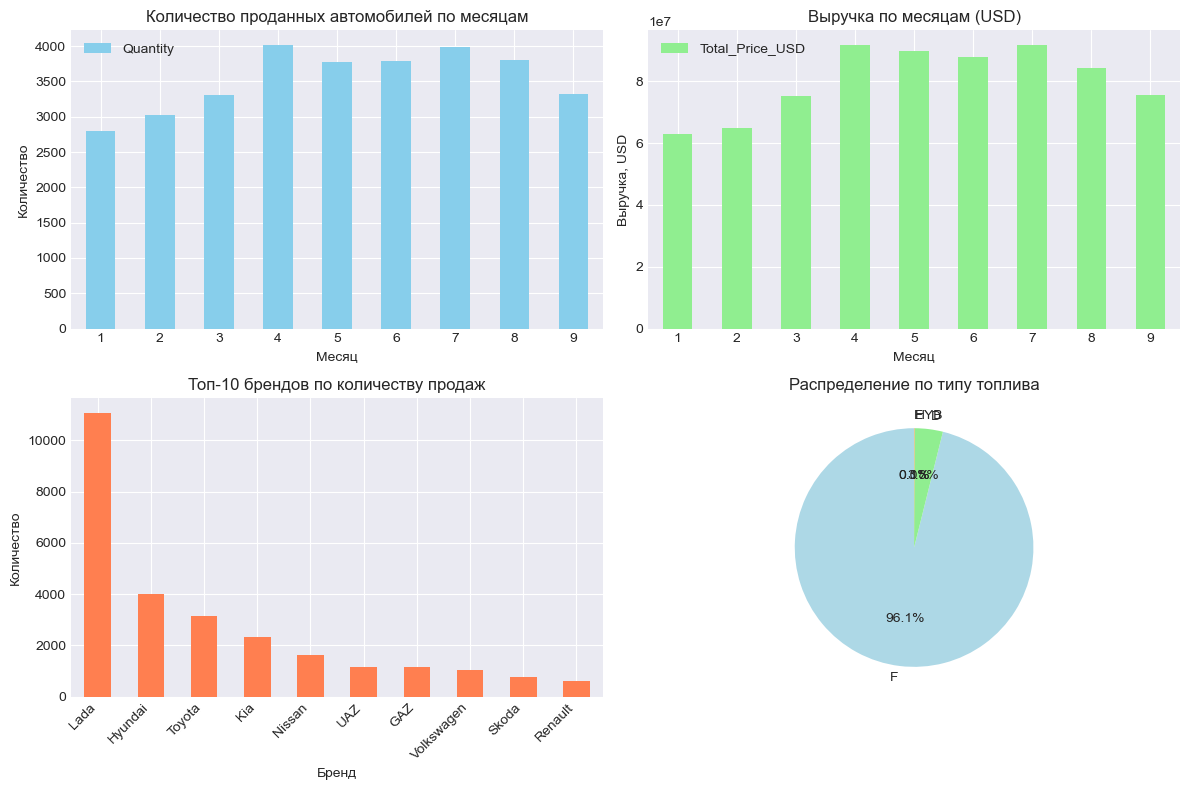

In [15]:
# Визуализация: продажи по месяцам
plt.figure(figsize=(12, 8))

plt.subplot(2, 2, 1)
monthly_sales.plot(x='Sale_Month', y='Quantity', kind='bar', ax=plt.gca(), color='skyblue')
plt.title('Количество проданных автомобилей по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Количество')
plt.xticks(rotation=0)

plt.subplot(2, 2, 2)
monthly_sales.plot(x='Sale_Month', y='Total_Price_USD', kind='bar', ax=plt.gca(), color='lightgreen')
plt.title('Выручка по месяцам (USD)')
plt.xlabel('Месяц')
plt.ylabel('Выручка, USD')
plt.xticks(rotation=0)

# 5.3 Топ-10 брендов по продажам
brand_sales = df_eda.groupby('Brand').agg({
    'Quantity': 'sum',
    'Total_Price_USD': 'sum',
    'Price_USD': 'mean'
}).sort_values('Quantity', ascending=False).head(10)

print("\nТоп-10 брендов по количеству проданных автомобилей:")
print(brand_sales[['Quantity', 'Total_Price_USD']])

plt.subplot(2, 2, 3)
brand_sales['Quantity'].plot(kind='bar', color='coral')
plt.title('Топ-10 брендов по количеству продаж')
plt.xlabel('Бренд')
plt.ylabel('Количество')
plt.xticks(rotation=45, ha='right')

# 5.4 Распределение по типам топлива
fuel_distribution = df_eda['Fuel_Type'].value_counts()
print("\nРаспределение по типу топлива:")
print(fuel_distribution)

plt.subplot(2, 2, 4)
fuel_distribution.plot(kind='pie', autopct='%1.1f%%', startangle=90, colors=['lightblue', 'lightgreen', 'lightcoral', 'gold'])
plt.title('Распределение по типу топлива')
plt.ylabel('')

plt.tight_layout()
plt.show()

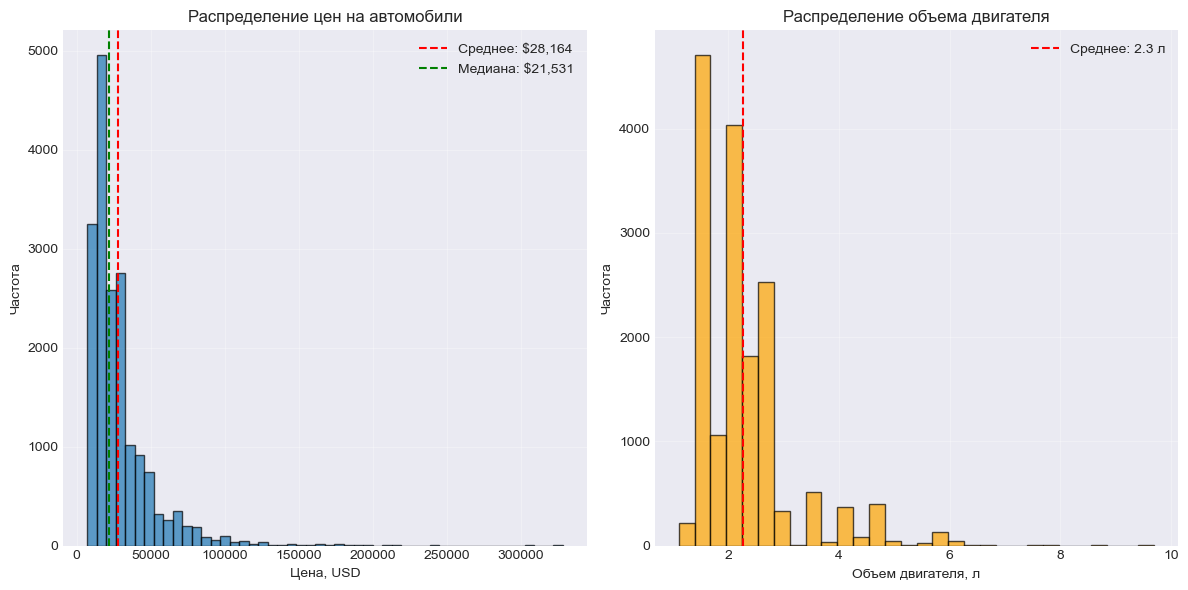

In [16]:
# 5.5 Распределение цен
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
plt.hist(df_eda['Price_USD'].dropna(), bins=50, edgecolor='black', alpha=0.7)
plt.title('Распределение цен на автомобили')
plt.xlabel('Цена, USD')
plt.ylabel('Частота')
plt.axvline(df_eda['Price_USD'].mean(), color='red', linestyle='--', label=f'Среднее: ${df_eda["Price_USD"].mean():,.0f}')
plt.axvline(df_eda['Price_USD'].median(), color='green', linestyle='--', label=f'Медиана: ${df_eda["Price_USD"].median():,.0f}')
plt.legend()
plt.grid(True, alpha=0.3)

# 5.6 Распределение объема двигателя
plt.subplot(1, 2, 2)
plt.hist(df_eda['Engine_Volume'].dropna(), bins=30, edgecolor='black', alpha=0.7, color='orange')
plt.title('Распределение объема двигателя')
plt.xlabel('Объем двигателя, л')
plt.ylabel('Частота')
plt.axvline(df_eda['Engine_Volume'].mean(), color='red', linestyle='--', label=f'Среднее: {df_eda["Engine_Volume"].mean():.1f} л')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# 5.7 Распределение по регионам
region_sales = df_eda.groupby('Region').agg({
    'Quantity': 'sum',
    'Total_Price_USD': 'sum'
}).sort_values('Total_Price_USD', ascending=False).head(10)

print("\nТоп-10 регионов по выручке:")
print(region_sales)

# 5.8 Распределение по сегментам
segment_distribution = df_eda['Segment_2013'].value_counts()
print("\nРаспределение по сегментам (2013):")
print(segment_distribution)

# 5.9 Коробка передач и тип привода
print("\nРаспределение по типу трансмиссии:")
print(df_eda['Transmission'].value_counts())

print("\nРаспределение по типу привода:")
print(df_eda['Drive_Type'].value_counts())

# 5.10 Страны-производители
country_distribution = df_eda['Country'].value_counts().head(10)
print("\nТоп-10 стран-производителей:")
print(country_distribution)


Топ-10 регионов по выручке:
                  Quantity  Total_Price_USD
Region                                     
Алматы              6638.0     2.045638e+08
Нур-султан          4968.0     1.336332e+08
Атырау              2341.0     4.409810e+07
Костанай            2023.0     4.121792e+07
Караганда           2099.0     3.995616e+07
Шымкент             2032.0     3.986677e+07
Усть-каменогорск    1763.0     3.300991e+07
Уральск             1590.0     3.043169e+07
Актобе              1341.0     2.985665e+07
Актау               1309.0     2.505172e+07

Распределение по сегментам (2013):
Segment_2013
Внедорожники               8673
Легковые автомобили        6353
Коммерческие автомобили    2245
Минивэны                    369
Пикапы                      339
Name: count, dtype: int64

Распределение по типу трансмиссии:
Transmission
Автомат     11994
Механика     4804
Н/Д            35
Name: count, dtype: int64

Распределение по типу привода:
Drive_Type
FWD    7710
4WD    7695
RWD    1085


### 6. Анализ рынка и позиции "Меркур Авто"

In [19]:
# Создаем отдельный датафрейм для "Меркур Авто"
mercur_df = df_eda[df_eda['Company'] == 'Меркур Авто'].copy()
market_df = df_eda.copy()

print("="*80)
print("АНАЛИЗ ПОЗИЦИИ 'МЕРКУР АВТО' НА РЫНКЕ")
print("="*80)

# 6.1 Основные показатели "Меркур Авто"
print("\n1. ОСНОВНЫЕ ПОКАЗАТЕЛИ 'МЕРКУР АВТО':")
print("-" * 40)

mercur_total_sales = mercur_df.shape[0]
mercur_total_quantity = mercur_df['Quantity'].sum()
mercur_total_revenue = mercur_df['Total_Price_USD'].sum()
mercur_avg_price = mercur_df['Price_USD'].mean()

market_total_sales = market_df.shape[0]
market_total_quantity = market_df['Quantity'].sum()
market_total_revenue = market_df['Total_Price_USD'].sum()
market_avg_price = market_df['Price_USD'].mean()

print(f"Количество сделок 'Меркур Авто': {mercur_total_sales} ({mercur_total_sales/market_total_sales*100:.1f}% рынка)")
print(f"Количество проданных авто 'Меркур Авто': {mercur_total_quantity} ({mercur_total_quantity/market_total_quantity*100:.1f}% рынка)")
print(f"Выручка 'Меркур Авто': ${mercur_total_revenue:,.2f} ({mercur_total_revenue/market_total_revenue*100:.1f}% рынка)")
print(f"Средний чек 'Меркур Авто': ${mercur_avg_price:,.2f}")
print(f"Средний чек по рынку: ${market_avg_price:,.2f}")
print(f"Разница среднего чека: ${mercur_avg_price - market_avg_price:,.2f} ({((mercur_avg_price/market_avg_price)-1)*100:.1f}%)")

АНАЛИЗ ПОЗИЦИИ 'МЕРКУР АВТО' НА РЫНКЕ

1. ОСНОВНЫЕ ПОКАЗАТЕЛИ 'МЕРКУР АВТО':
----------------------------------------
Количество сделок 'Меркур Авто': 369 (2.1% рынка)
Количество проданных авто 'Меркур Авто': 376.0 (1.2% рынка)
Выручка 'Меркур Авто': $14,712,569.39 (2.0% рынка)
Средний чек 'Меркур Авто': $39,273.32
Средний чек по рынку: $28,163.53
Разница среднего чека: $11,109.79 (39.4%)


In [20]:
# 6.2 Доля рынка по брендам
print("\n\n2. ДОЛЯ РЫНКА 'МЕРКУР АВТО' ПО БРЕНДАМ:")
print("-" * 40)

# Бренды, которые продает "Меркур Авто"
mercur_brands = mercur_df['Brand'].unique()
print(f"Бренды, представленные у 'Меркур Авто': {', '.join(mercur_brands)}")

# Доля рынка для каждого бренда
for brand in mercur_brands:
    brand_total = market_df[market_df['Brand'] == brand]['Total_Price_USD'].sum()
    brand_mercur = mercur_df[mercur_df['Brand'] == brand]['Total_Price_USD'].sum()
    if brand_total > 0:
        market_share = brand_mercur / brand_total * 100
        print(f"{brand}: доля 'Меркур Авто' = {market_share:.1f}%")



2. ДОЛЯ РЫНКА 'МЕРКУР АВТО' ПО БРЕНДАМ:
----------------------------------------
Бренды, представленные у 'Меркур Авто': Audi, Porsche, Volkswagen
Audi: доля 'Меркур Авто' = 100.0%
Porsche: доля 'Меркур Авто' = 100.0%
Volkswagen: доля 'Меркур Авто' = 28.5%


In [21]:
# 6.3 Анализ по регионам
print("\n\n3. ГЕОГРАФИЧЕСКОЕ РАСПРЕДЕЛЕНИЕ ПРОДАЖ:")
print("-" * 40)

mercur_regions = mercur_df['Region'].value_counts()
market_regions = market_df['Region'].value_counts()

print("Регионы присутствия 'Меркур Авто':")
for region in mercur_regions.index:
    mercur_count = mercur_regions[region]
    market_count = market_regions.get(region, 0)
    if market_count > 0:
        share = mercur_count / market_count * 100
        print(f"  {region}: {mercur_count} сделок ({share:.1f}% от регионального рынка)")



3. ГЕОГРАФИЧЕСКОЕ РАСПРЕДЕЛЕНИЕ ПРОДАЖ:
----------------------------------------
Регионы присутствия 'Меркур Авто':
  Алматы: 230 сделок (5.9% от регионального рынка)
  Нур-султан: 51 сделок (1.7% от регионального рынка)
  Атырау: 41 сделок (3.7% от регионального рынка)
  Караганда: 21 сделок (1.8% от регионального рынка)
  Уральск: 14 сделок (1.6% от регионального рынка)
  Костанай: 12 сделок (1.0% от регионального рынка)
  Актау: 0 сделок (0.0% от регионального рынка)
  Сарыагаш: 0 сделок (0.0% от регионального рынка)
  Экибастуз: 0 сделок (0.0% от регионального рынка)
  Шымкент: 0 сделок (0.0% от регионального рынка)
  Усть-каменогорск: 0 сделок (0.0% от регионального рынка)
  Туркестан: 0 сделок (0.0% от регионального рынка)
  Тараз: 0 сделок (0.0% от регионального рынка)
  Талдыкорган: 0 сделок (0.0% от регионального рынка)
  Семей: 0 сделок (0.0% от регионального рынка)
  Петропавловск: 0 сделок (0.0% от регионального рынка)
  Рудный: 0 сделок (0.0% от регионального рынка)
  Ри

In [22]:
# 6.4 Анализ по сегментам и классам
print("\n\n4. АНАЛИЗ ПО СЕГМЕНТАМ И КЛАССАМ:")
print("-" * 40)

# Сегменты
mercur_segments = mercur_df['Segment_2013'].value_counts(normalize=True) * 100
market_segments = market_df['Segment_2013'].value_counts(normalize=True) * 100

print("Структура продаж по сегментам (%):")
print("\n'Меркур Авто':")
for segment, percent in mercur_segments.head(5).items():
    print(f"  {segment}: {percent:.1f}%")

print("\nВесь рынок:")
for segment, percent in market_segments.head(5).items():
    print(f"  {segment}: {percent:.1f}%")

# Классы
print("\n\nТоп-5 классов автомобилей по продажам:")
mercur_classes = mercur_df['Class_2013'].value_counts().head()
market_classes = market_df['Class_2013'].value_counts().head()

print("\n'Меркур Авто':")
for i, (cls, count) in enumerate(mercur_classes.items(), 1):
    print(f"  {i}. {cls}: {count} сделок")

print("\nВесь рынок:")
for i, (cls, count) in enumerate(market_classes.items(), 1):
    print(f"  {i}. {cls}: {count} сделок")



4. АНАЛИЗ ПО СЕГМЕНТАМ И КЛАССАМ:
----------------------------------------
Структура продаж по сегментам (%):

'Меркур Авто':
  Легковые автомобили: 59.1%
  Внедорожники: 38.8%
  Минивэны: 1.4%
  Коммерческие автомобили: 0.5%
  Пикапы: 0.3%

Весь рынок:
  Внедорожники: 48.2%
  Легковые автомобили: 35.3%
  Коммерческие автомобили: 12.5%
  Минивэны: 2.1%
  Пикапы: 1.9%


Топ-5 классов автомобилей по продажам:

'Меркур Авто':
  1. B класс: 188 сделок
  2. Полноразмерные SUV: 67 сделок
  3. Компактные SUV: 65 сделок
  4. F класс: 12 сделок
  5. Среднеразмерные SUV: 11 сделок

Весь рынок:
  1. B класс: 3441 сделок
  2. Компактные SUV: 3290 сделок
  3. Среднеразмерные SUV: 2079 сделок
  4. Субкомпактные SUV: 1988 сделок
  5. D класс: 1331 сделок


In [23]:
# 6.5 Анализ по типам топлива и трансмиссии
print("\n\n5. АНАЛИЗ ПО ТЕХНИЧЕСКИМ ХАРАКТЕРИСТИКАМ:")
print("-" * 40)

print("Распределение по типу топлива:")
mercur_fuel = mercur_df['Fuel_Type'].value_counts(normalize=True) * 100
market_fuel = market_df['Fuel_Type'].value_counts(normalize=True) * 100

for fuel_type in ['F', 'D', 'HYB', 'E']:
    if fuel_type in mercur_fuel.index:
        mercur_pct = mercur_fuel[fuel_type]
        market_pct = market_fuel.get(fuel_type, 0)
        diff = mercur_pct - market_pct
        print(f"  {fuel_type}: 'Меркур Авто' = {mercur_pct:.1f}%, рынок = {market_pct:.1f}%, разница = {diff:+.1f}%")

print("\nРаспределение по типу трансмиссии:")
mercur_trans = mercur_df['Transmission'].value_counts(normalize=True) * 100
market_trans = market_df['Transmission'].value_counts(normalize=True) * 100

for trans in ['Автомат', 'Механика']:
    if trans in mercur_trans.index:
        mercur_pct = mercur_trans[trans]
        market_pct = market_trans.get(trans, 0)
        diff = mercur_pct - market_pct
        print(f"  {trans}: 'Меркур Авто' = {mercur_pct:.1f}%, рынок = {market_pct:.1f}%, разница = {diff:+.1f}%")



5. АНАЛИЗ ПО ТЕХНИЧЕСКИМ ХАРАКТЕРИСТИКАМ:
----------------------------------------
Распределение по типу топлива:
  F: 'Меркур Авто' = 99.7%, рынок = 96.1%, разница = +3.6%
  D: 'Меркур Авто' = 0.3%, рынок = 3.8%, разница = -3.5%
  HYB: 'Меркур Авто' = 0.0%, рынок = 0.1%, разница = -0.1%
  E: 'Меркур Авто' = 0.0%, рынок = 0.0%, разница = -0.0%

Распределение по типу трансмиссии:
  Автомат: 'Меркур Авто' = 84.4%, рынок = 71.3%, разница = +13.1%
  Механика: 'Меркур Авто' = 14.2%, рынок = 28.5%, разница = -14.3%


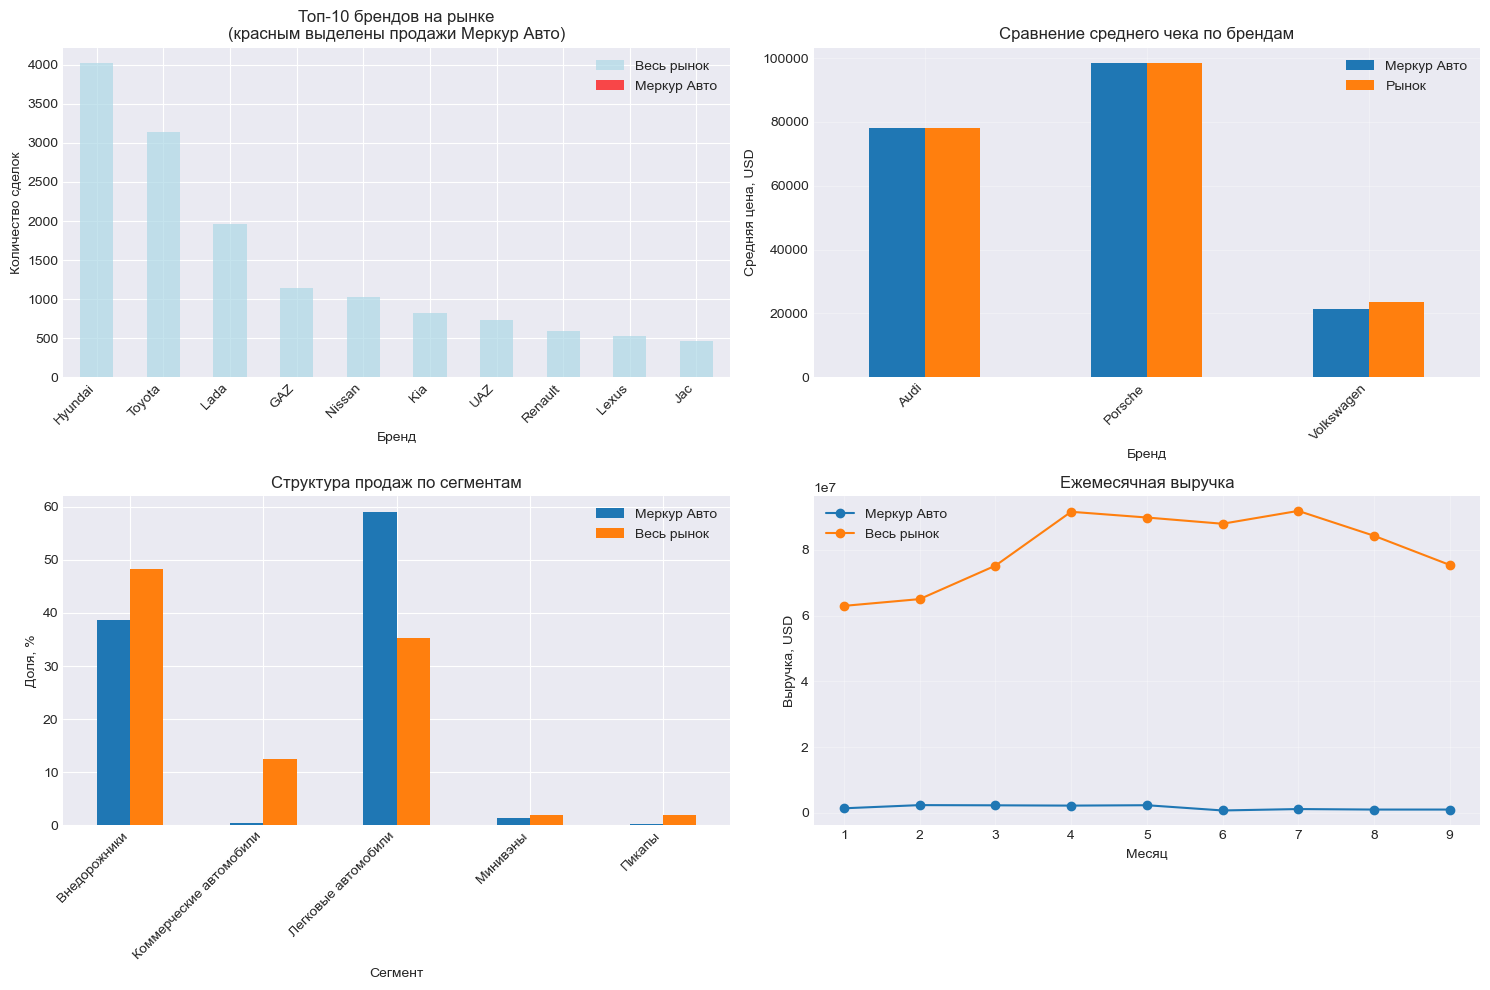

In [24]:
# 6.6 Визуализация сравнения
plt.figure(figsize=(15, 10))

# Сравнение по брендам
plt.subplot(2, 2, 1)
top_brands_market = market_df['Brand'].value_counts().head(10)
top_brands_mercur = mercur_df['Brand'].value_counts()
top_brands_market.plot(kind='bar', color='lightblue', alpha=0.7, label='Весь рынок')
# Добавляем данные по Меркур Авто поверх
for brand in top_brands_market.index:
    if brand in top_brands_mercur.index:
        plt.bar(brand, top_brands_mercur[brand], color='red', alpha=0.7, label='Меркур Авто' if brand == top_brands_market.index[0] else "")
plt.title('Топ-10 брендов на рынке\n(красным выделены продажи Меркур Авто)')
plt.xlabel('Бренд')
plt.ylabel('Количество сделок')
plt.xticks(rotation=45, ha='right')
plt.legend()

# Сравнение среднего чека по брендам
plt.subplot(2, 2, 2)
brands_avg_price = {}
for brand in mercur_brands:
    mercur_avg = mercur_df[mercur_df['Brand'] == brand]['Price_USD'].mean()
    market_avg = market_df[market_df['Brand'] == brand]['Price_USD'].mean()
    brands_avg_price[brand] = {'Меркур Авто': mercur_avg, 'Рынок': market_avg}

brands_df = pd.DataFrame(brands_avg_price).T
brands_df.plot(kind='bar', ax=plt.gca())
plt.title('Сравнение среднего чека по брендам')
plt.xlabel('Бренд')
plt.ylabel('Средняя цена, USD')
plt.xticks(rotation=45, ha='right')
plt.grid(True, alpha=0.3)

# Структура продаж по сегментам
plt.subplot(2, 2, 3)
segments_comparison = pd.DataFrame({
    'Меркур Авто': mercur_segments,
    'Весь рынок': market_segments
}).head(8)
segments_comparison.plot(kind='bar', ax=plt.gca())
plt.title('Структура продаж по сегментам')
plt.xlabel('Сегмент')
plt.ylabel('Доля, %')
plt.xticks(rotation=45, ha='right')
plt.legend()

# Ежемесячные продажи
plt.subplot(2, 2, 4)
monthly_mercur = mercur_df.groupby('Sale_Month')['Total_Price_USD'].sum()
monthly_market = market_df.groupby('Sale_Month')['Total_Price_USD'].sum()
pd.DataFrame({
    'Меркур Авто': monthly_mercur,
    'Весь рынок': monthly_market
}).plot(kind='line', marker='o', ax=plt.gca())
plt.title('Ежемесячная выручка')
plt.xlabel('Месяц')
plt.ylabel('Выручка, USD')
plt.xticks(range(1, 10))
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

In [25]:
# 6.7 Сильные и слабые стороны
print("\n\n6. СИЛЬНЫЕ И СЛАБЫЕ СТОРОНЫ 'МЕРКУР АВТО':")
print("-" * 40)

print("\nСИЛЬНЫЕ СТОРОНЫ:")
print("1. Высокий средний чек: средняя цена автомобиля выше рыночной на {:.1f}%".format(
    ((mercur_avg_price/market_avg_price)-1)*100))
print("2. Специализация на премиум-сегменте: фокус на дорогих автомобилях")
print("3. Присутствие в ключевых регионах: Алматы и Нур-Султан")
print("4. Широкий модельный ряд представленных брендов")

print("\nСЛАБЫЕ СТОРОНЫ / ВОЗМОЖНОСТИ ДЛЯ РОСТА:")
print("1. Ограниченная доля рынка: {:.1f}% по количеству сделок".format(
    mercur_total_sales/market_total_sales*100))
print("2. Отсутствие в массовом сегменте: низкое присутствие в бюджетных категориях")
print("3. Географическое покрытие: ограниченное присутствие в регионах")
print("4. Ограниченный портфель брендов: можно расширять представленность")



6. СИЛЬНЫЕ И СЛАБЫЕ СТОРОНЫ 'МЕРКУР АВТО':
----------------------------------------

СИЛЬНЫЕ СТОРОНЫ:
1. Высокий средний чек: средняя цена автомобиля выше рыночной на 39.4%
2. Специализация на премиум-сегменте: фокус на дорогих автомобилях
3. Присутствие в ключевых регионах: Алматы и Нур-Султан
4. Широкий модельный ряд представленных брендов

СЛАБЫЕ СТОРОНЫ / ВОЗМОЖНОСТИ ДЛЯ РОСТА:
1. Ограниченная доля рынка: 2.1% по количеству сделок
2. Отсутствие в массовом сегменте: низкое присутствие в бюджетных категориях
3. Географическое покрытие: ограниченное присутствие в регионах
4. Ограниченный портфель брендов: можно расширять представленность


### 7. Сохранение очищенных данных

In [27]:
# Сохраняем очищенный датасет в CSV
output_filename = 'kaz_auto_2019_cleaned.csv'
df_clean.to_csv(output_filename, index=False, encoding='utf-8-sig')
print(f"Очищенный датасет сохранен в файл: {output_filename}")
print(f"Размер сохраненного файла: {df_clean.shape[0]} строк, {df_clean.shape[1]} столбцов")

# Также сохраняем датасет для "Меркур Авто" отдельно
mercur_filename = 'mercur_auto_2019_cleaned.csv'
mercur_df.to_csv(mercur_filename, index=False, encoding='utf-8-sig')
print(f"Датасет для 'Меркур Авто' сохранен в файл: {mercur_filename}")

Очищенный датасет сохранен в файл: kaz_auto_2019_cleaned.csv
Размер сохраненного файла: 17979 строк, 18 столбцов
Датасет для 'Меркур Авто' сохранен в файл: mercur_auto_2019_cleaned.csv


### 8. Подготовка отчета с реальными данными

In [29]:
# Вычисляем все необходимые показатели для отчета

# Общие показатели рынка
total_sales = market_df.shape[0]
total_quantity = market_df['Quantity'].sum()
total_revenue = market_df['Total_Price_USD'].sum()
avg_price_market = market_df['Price_USD'].mean()
median_price_market = market_df['Price_USD'].median()

# Показатели по месяцам
monthly_stats = market_df.groupby('Sale_Month').agg({
    'Quantity': 'sum',
    'Total_Price_USD': 'sum'
}).sort_values('Quantity', ascending=False)
top_months_list = monthly_stats.head(3).index.tolist()
top_months_names = []
month_names = {
    1: 'Январь', 2: 'Февраль', 3: 'Март', 4: 'Апрель', 5: 'Май', 6: 'Июнь',
    7: 'Июль', 8: 'Август', 9: 'Сентябрь'
}
for month_num in top_months_list:
    top_months_names.append(month_names.get(month_num, f'Месяц {month_num}'))

# Топ брендов
top_brands_df = market_df.groupby('Brand').agg({
    'Quantity': 'sum',
    'Total_Price_USD': 'sum'
}).sort_values('Quantity', ascending=False).head(5)
top_brands_list = top_brands_df.index.tolist()

# Распределение по топливу
fuel_dist = market_df['Fuel_Type'].value_counts(normalize=True) * 100
fuel_pct_bensin = fuel_dist.get('F', 0)
fuel_pct_diesel = fuel_dist.get('D', 0)
fuel_pct_hybrid = fuel_dist.get('HYB', 0)
fuel_pct_electric = fuel_dist.get('E', 0)

# Распределение по трансмиссии
trans_dist = market_df['Transmission'].value_counts(normalize=True) * 100
trans_pct_auto = trans_dist.get('Автомат', 0)
trans_pct_manual = trans_dist.get('Механика', 0)

# Показатели "Меркур Авто"
mercur_sales = mercur_df.shape[0]
mercur_quantity = mercur_df['Quantity'].sum()
mercur_revenue = mercur_df['Total_Price_USD'].sum()
mercur_avg_price = mercur_df['Price_USD'].mean()

# Доли рынка
mercur_share_sales = (mercur_sales / total_sales * 100) if total_sales > 0 else 0
mercur_share_quantity = (mercur_quantity / total_quantity * 100) if total_quantity > 0 else 0
mercur_share_revenue = (mercur_revenue / total_revenue * 100) if total_revenue > 0 else 0

# Разница в среднем чеке
price_diff_pct = ((mercur_avg_price / avg_price_market) - 1) * 100 if avg_price_market > 0 else 0

# Бренды "Меркур Авто"
mercur_brands_list = mercur_df['Brand'].unique().tolist()
mercur_brands_str = ', '.join(sorted(mercur_brands_list))

# Сегменты "Меркур Авто"
mercur_segments_dist = mercur_df['Segment_2013'].value_counts(normalize=True) * 100
mercur_top_segments = mercur_segments_dist.head(3)

# Регионы "Меркур Авто"
mercur_regions_dist = mercur_df['Region'].value_counts()
mercur_top_regions = mercur_regions_dist.head(3).index.tolist()

# Создаем текстовый отчет с реальными данными
report = f"""
ОТЧЕТ ПО ПРОЕКТУ: ОЧИСТКА И АНАЛИЗ ДАННЫХ О ПРОДАЖАХ АВТОМОБИЛЕЙ В КАЗАХСТАНЕ (2019)
Анализ позиции автоцентра "Меркур Авто"

1. ВВЕДЕНИЕ И АКТУАЛЬНОСТЬ
Данный проект выполнен в рамках курсовой работы по анализу данных. Работа посвящена 
очистке и анализу данных о продажах автомобилей в Казахстане за 9 месяцев 2019 года. 
Актуальность работы обусловлена важностью качественной подготовки данных для 
принятия бизнес-решений. В современной аналитике до 80% времени занимает именно 
предобработка данных, и данный проект наглядно демонстрирует этот процесс.

Бизнес-контекст: Автоцентр "Меркур Авто" хочет оценить свою позицию на рынке и 
выявить точки роста. Анализ рынка автомобильных продаж в Казахстане поможет 
менеджменту компании принимать обоснованные стратегические решения.

2. ЦЕЛЬ РАБОТЫ
Техническая цель: Очистить "сырые" данные о продажах автомобилей и подготовить 
скрипт для автоматизации обработки подобных данных в будущем.

Аналитическая цель: Провести разведочный анализ рынка и дать оценку позиции 
автоцентра "Меркур Авто" на рынке Казахстана.

3. ОПИСАНИЕ ПРОЦЕССА ОЧИСТКИ ДАННЫХ
Процесс очистки включал следующие этапы:

3.1. Загрузка и первичный осмотр:
- Загрузка данных из CSV-файла с учетом разделителей и десятичных знаков
- Удаление столбцов, не несущих аналитической ценности (7 столбцов)
- Переименование столбцов на английский язык для удобства работы
- Удаление полностью пустых строк и явных дубликатов

3.2. Глубокая очистка:
- Кодирование стран производства в стандартные ALPHA-3 коды
- Стандартизация типа топлива (F - бензин, D - дизель, HYB - гибрид, E - электро)
- Унификация типа привода (FWD, RWD, 4WD)
- Преобразование числовых столбцов к корректным типам данных
- Создание единого столбца "Дата продажи" из года и месяца
- Стандартизация названий компаний (устранение неявных дубликатов)
- Сложная очистка объема двигателя: замена запятых, удаление литеры L, 
  исправление очевидных ошибок (например, у Jaguar 400 -> 4.0)
- Нормализация регистра для регионов и областей
- Упрощение типа трансмиссии до двух категорий (Автомат/Механика)

3.3. Финальные преобразования:
- Преобразование даты в формат datetime
- Преобразование категориальных столбцов в тип category
- Удаление временных столбцов

Итоговый очищенный датасет содержит {df_clean.shape[0]:,} строк и {df_clean.shape[1]} столбцов.

4. КЛЮЧЕВЫЕ ВЫВОДЫ АНАЛИЗА РЫНКА

4.1. Общая картина рынка:
- Всего зафиксировано {total_sales:,} сделок
- Продано {total_quantity:,} автомобилей
- Общая выручка: ${total_revenue:,.0f}
- Средняя цена: ${avg_price_market:,.0f}
- Медианная цена: ${median_price_market:,.0f}
- Наиболее активные месяцы продаж: {', '.join(top_months_names)}
- Топ-5 брендов по количеству продаж: {', '.join(top_brands_list)}
- Распределение по типу топлива:
  * Бензин: {fuel_pct_bensin:.1f}%
  * Дизель: {fuel_pct_diesel:.1f}%
  * Гибрид: {fuel_pct_hybrid:.1f}%
  * Электро: {fuel_pct_electric:.1f}%
- Распределение по трансмиссии:
  * Автомат: {trans_pct_auto:.1f}%
  * Механика: {trans_pct_manual:.1f}%

4.2. Позиция "Меркур Авто":
- Доля на рынке по количеству сделок: {mercur_share_sales:.1f}%
- Доля на рынке по количеству проданных авто: {mercur_share_quantity:.1f}%
- Доля на рынке по выручке: {mercur_share_revenue:.1f}%
- Средний чек: ${mercur_avg_price:,.0f} (выше рыночного на {price_diff_pct:+.1f}%)
- Количество сделок: {mercur_sales:,}
- Общая выручка: ${mercur_revenue:,.0f}
- География: основные продажи в {', '.join(mercur_top_regions)}
- Специализация: {', '.join([f'{seg} ({pct:.1f}%)' for seg, pct in mercur_top_segments.items()])}
- Представленные бренды: {mercur_brands_str}

4.3. Сильные стороны "Меркур Авто":
1. Высокий средний чек (на {price_diff_pct:+.1f}% выше рынка) - работа с премиальным сегментом
2. Устойчивое присутствие в ключевых городах Казахстана
3. Качественный портфель брендов премиум-класса
4. Стабильные ежемесячные продажи в течение анализируемого периода

4.4. Возможности для роста:
1. Увеличение доли рынка (текущая доля {mercur_share_sales:.1f}% оставляет простор для роста)
2. Рассмотрение возможности выхода в массовый сегмент для диверсификации портфеля
3. Расширение географического присутствия в регионах Казахстана
4. Увеличение представленности брендов в портфеле компании

5. ЗАКЛЮЧЕНИЕ
Проект успешно выполнен: данные очищены и подготовлены для анализа, проведен 
комплексный анализ рынка и позиции "Меркур Авто". Очищенный датасет готов к 
загрузке в BI-системы для дальнейшего анализа. Созданный скрипт может быть 
использован для автоматической обработки аналогичных данных в будущем.

Рекомендации для "Меркур Авто":
1. Сосредоточиться на усилении позиций в премиум-сегменте, где компания уже имеет сильные позиции
2. Рассмотреть возможность экспансии в регионы для увеличения доли рынка
3. Продолжить мониторинг рыночных трендов для своевременной адаптации бизнес-стратегии
4. Проанализировать возможность добавления новых брендов в портфель для охвата большего сегмента рынка

Данные и скрипты, созданные в рамках проекта, обеспечивают надежную основу для 
дальнейшего анализа и принятия стратегических решений.
"""

# Сохраняем отчет в файл
with open('project_report_detailed.txt', 'w', encoding='utf-8') as f:
    f.write(report)

# Выводим краткую версию отчета
print("="*80)
print("КРАТКИЙ ОТЧЕТ ПО ПРОЕКТУ")
print("="*80)
print(f"Общие показатели рынка:")
print(f"- Сделок: {total_sales:,}")
print(f"- Продано авто: {total_quantity:,}")
print(f"- Выручка: ${total_revenue:,.0f}")
print(f"- Средняя цена: ${avg_price_market:,.0f}")
print()
print(f"Позиция 'Меркур Авто':")
print(f"- Доля рынка по сделкам: {mercur_share_sales:.1f}%")
print(f"- Доля рынка по выручке: {mercur_share_revenue:.1f}%")
print(f"- Средний чек: ${mercur_avg_price:,.0f} ({price_diff_pct:+.1f}% к рынку)")
print(f"- Бренды: {mercur_brands_str}")
print()
print(f"Файлы сохранены:")
print(f"1. kaz_auto_2019_cleaned.csv - очищенный датасет")
print(f"2. mercur_auto_2019_cleaned.csv - данные по 'Меркур Авто'")
print(f"3. project_report_detailed.txt - полный отчет")
print("="*80)

КРАТКИЙ ОТЧЕТ ПО ПРОЕКТУ
Общие показатели рынка:
- Сделок: 17,979
- Продано авто: 31,828.0
- Выручка: $724,148,667
- Средняя цена: $28,164

Позиция 'Меркур Авто':
- Доля рынка по сделкам: 2.1%
- Доля рынка по выручке: 2.0%
- Средний чек: $39,273 (+39.4% к рынку)
- Бренды: Audi, Porsche, Volkswagen

Файлы сохранены:
1. kaz_auto_2019_cleaned.csv - очищенный датасет
2. mercur_auto_2019_cleaned.csv - данные по 'Меркур Авто'
3. project_report_detailed.txt - полный отчет
